# 8. PyTorch primer 

![](https://the-decoder.com/wp-content/uploads/2022/09/PyTorch-Logo.png)

## Objetivos

- Introducir uso de `pytorch`
    - Instalación local
    - Descubriendo GPUs
- Comprender como funciona el módulo `autograd`
- Redes neuronales
    - Ciclo de entrenamiento
    - Definición de una red
    - Optimización
    - Representación de embeddings

### ¿Qué es pytorch?

[PyTorch](https://pytorch.org/) es un framework para hacer *Deep Learning*, y es uno de los más populares junto con [Tensorflow](https://www.tensorflow.org/?hl=es). Su instalación puede realizarse de muchas formas distintas ya sea si querramos habilitar soporte para aceleradores (como una GPU) o si solo queremos soporte para CPU. Más información sobre su instalación en la [documentación](https://pytorch.org/get-started/locally/).

La forma más sencilla de comenzar a utilizar `PyTorch` probablemente sería en un [Notebook de Colab](https://colab.research.google.com/) donde ya está configurado el paquete para utilizar los aceleradores disponibles (dependiendo del [entorno seleccionado](https://research.google.com/colaboratory/faq.html#gpu-availability))

![](https://media.licdn.com/dms/image/v2/C5622AQEfw4J2wKWv8A/feedshare-shrink_2048_1536/feedshare-shrink_2048_1536/0/1642765164494?e=2147483647&v=beta&t=d9Wav5tdJWOpzSmJ8rtITz3zw1ca3i2xsiD3yShiwH4)

#### Local first (?)

Recomiendo ampliamente utilizar `uv` y seguir [su documentación](https://docs.astral.sh/uv/guides/integration/pytorch/) para gestionar proyectos que utilicen `pytorch`

In [ ]:
import torch
from rich import print as rprint

In [6]:
rprint(f"Is CUDA available? {torch.cuda.is_available()}")
gpu_count = torch.cuda.device_count()

for i in range(gpu_count):
    rprint(f"GPU {i}: {torch.cuda.get_device_name(i)}")

Is CUDA available? False

### Tensores

Los **Tensores** son el bloque de construcción más básico de `PyTorch`. Cada tensor puede verse como una matríz multidimensional que representará datos en nuestros *pipelines* de entrenamiendo. Por ejemplo, una imágen de 256x256 puede representarse como un tensor de `3x256x256` donde la primera dimensión representará el color.

In [4]:
data = torch.tensor(
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ]
)
rprint(data)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [5]:
data.shape

torch.Size([3, 3])

`PyTorch` permite la inter-conversión con arreglos de `numpy`

In [7]:
import numpy as np 


array = np.array([[1, 0, 5]])
data = torch.tensor(array)
rprint("Tensor:", data)

new_array = data.numpy()
rprint("np array:", new_array)

Tensor: tensor([[1, 0, 5]])

np array: [[1 0 5]]

Los tensores nos permite realizar *operaciones vectorizadas*: operaciones que se realizan en paralelo sobre alguna dimensión particular del tensor.

In [15]:
data = torch.arange(1, 36, dtype=torch.float32)
rprint("[bold bright_yellow]Data")
rprint(data)

data = data.reshape(5, 7)
rprint("[bold bright_yellow]Reshaped Data")
rprint(data)

rprint("Sumando sobre las filas ([bright_green]dim=1[/]): ")
rprint(data.sum(dim=1)) # (5,)

rprint("Sumando sobre las columnas ([bright_green]dim=0[/]): ")
rprint(data.sum(dim=0)) # (7,)

rprint("Promedio sobre las filas ([bright_green]dim=1[/]): ")
rprint(data.mean(dim=1)) # (5,)

rprint("Calculando stdev sobre las filas ([bright_green]dim=1[/]):")
rprint(data.std(dim=1))

Data

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14.,
        15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28.,
        29., 30., 31., 32., 33., 34., 35.])

Reshaped Data

tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19., 20., 21.],
        [22., 23., 24., 25., 26., 27., 28.],
        [29., 30., 31., 32., 33., 34., 35.]])

Sumando sobre las filas (dim=1):

...

tensor([ 75.,  80.,  85.,  90.,  95., 100., 105.])

Promedio sobre las filas (dim=1):

tensor([ 4., 11., 18., 25., 32.])

Calculando stdev sobre las filas (dim=1):

tensor([2.1602, 2.1602, 2.1602, 2.1602, 2.1602])

In [22]:
data = torch.arange(1, 7, dtype=torch.float32).reshape(1, 2, 3)
rprint("[bold bright_yellow]Data")
rprint(data)
rprint(data.sum(dim=0).sum(dim=0))
rprint(data.sum(dim=0).sum(dim=0).shape)

Data

tensor([[[1., 2., 3.],
         [4., 5., 6.]]])

tensor([5., 7., 9.])

torch.Size([3])

In [17]:
rprint(data.sum())

tensor(21.)

### Indexado

In [23]:
X = torch.tensor(
    [
        [[1, 2], [3, 4]],
        [[5, 6], [7, 8]],
        [[9, 10], [11, 12]]
    ]
)
rprint(X)

tensor([[[ 1,  2],
         [ 3,  4]],

        [[ 5,  6],
         [ 7,  8]],

        [[ 9, 10],
         [11, 12]]])

In [24]:
rprint(X.shape)

torch.Size([3, 2, 2])

In [27]:
# Equivale a X[0, :]
rprint(X[0])

tensor([[1, 2],
        [3, 4]])

In [28]:
# Obtenemos de todas las columnas el elemento 1
rprint(X[:, 1])

tensor([[ 3,  4],
        [ 7,  8],
        [11, 12]])

In [ ]:
# Obtenemos de todas las columnas
# del elemento 0 y de esos tensores el elemento 0
rprint(X[:, 0, 0])

tensor([1, 5, 9])

In [30]:
rprint(X[:,:,:])

tensor([[[ 1,  2],
         [ 3,  4]],

        [[ 5,  6],
         [ 7,  8]],

        [[ 9, 10],
         [11, 12]]])

In [31]:
# Accediendo a los elementos 0 y 1, dos veces
i = torch.tensor([0, 0, 1, 1])
X[i]

tensor([[[1, 2],
         [3, 4]],

        [[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]],

        [[5, 6],
         [7, 8]]])

In [ ]:
# Accediendo al elemento 0 del tensor 1 y 2
i = torch.tensor([1, 2])
j = torch.tensor([0])
X[i, j]

tensor([[ 5,  6],
        [ 9, 10]])

In [33]:
X[0, 0, 0]

tensor(1)

In [34]:
# Obtenemos el escalar
X[0, 0, 0].item()

1

### Dispositivos y operaciones

`Pytorch` permite ejecutar muchas operaciones con tensores, incluyendo transposición, indexación, segmentación (slicing), operaciones matemáticas, álgebra lineal, muestreo aleatorio y etc. Pueden encontrar más información en la [docu](https://docs.pytorch.org/docs/stable/torch.html#math-operations).

Cada una de ellas puede ejecutarse en la GPU (generalmente a velocidades superiores que en un CPU).

In [43]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.4729, 0.7544, 0.3560],
        [0.3435, 0.9299, 0.1329]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [44]:
rprint(f"Device tensor is stored on: {rand_tensor.device}")

# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = rand_tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cpu

## Autograd

`PyTorch` es bien conocido por realizar diferenciación automática. Llamando el método `backward()` se calculará el gradiente y se guardará en el atributo `grad`.

In [45]:
# Creamos un tensor de ejemplo
# requires_grad indica explicitamente que se guarden los gradientes
x = torch.tensor([10.], requires_grad=True)

# El gradiente de un escalar será None
rprint(x.grad)

None

$$
\frac{\partial(y)}{\partial(x)} = \frac{\partial 3x^2}{\partial x} = 6x
$$

In [46]:
# Calculamos el gradiente de y con respecto a x
y = 3 * x ** 2
y.backward()
# d(y)/d(x) = d(3x^2)/d(x) = 6x = 60
rprint(y, x.grad.item())

tensor([300.], grad_fn=<MulBackward0>) 60.0

Corriendo *backpropagation* para un tensor distinto

In [47]:
z = 3 * x ** 2
z.backward()
# d(z)/d(x) = d(3x^2)/d(x) = 6x = 60
rprint(y, x.grad.item())

tensor([300.], grad_fn=<MulBackward0>) 120.0

In [48]:
x.grad = None
z = 3 * x ** 2
z.backward()
rprint(x.grad.item())

60.0

Podemos ver que `x.grad` es actualizado con la suma de los gradientes calculados. Cuando se realiza *backpropagation* en una red neuronal, se suman el gradiante de una neurona particular antes de hacer la actualización. Esta es la razón por la que se utiliza el método `zero_grad()` en cada iteración de entrenamiento. De otro modo se estaría acumulando el gradiente calculado de una iteración a otra dando como resultado resultados erroneos.

**NOTA:** Se puede personalizar la [función de backward](https://docs.pytorch.org/docs/stable/notes/extending.html)

## Un ciclo de entrenamiento completo en Redes Neuronales

### ¿Cómo se entrena una red neuronal?

Una red neuronal puede verse como una colección de funciones anidadas que operan sobre alguna entrada. Estas funciones estan definidas de forma paramétrica (pesos ($w$) y biases ($b$)), que con pytorch son guardados en tensores.

El entrenamiento sucede en dos pasos:

1. **Forward pass**: En este paso la *NN*, realiza una predicción intentado obteniendo una salida.Los datos de entrada fluyen por cada funcion que componen la red para realizar esta predicción.
2. **Backward pass**: En este paso la *NN* ajusta los parametros proporcionalmente al error de la predicción. Para hacer esto retrocede desde la salida, recopila las derivadas del error con respecto a los parámetros de las funciones (gradientes) y optimiza los parámetros mediante el descenso de gradiente. Explicación detallada de este paso en [este video de 3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8)

### Entrenando con `pytorch`

- Cargamos un modelo `resnet18` previamente entrenado desde `torchvision`. 
- Creamos un tensor de datos aleatorios para representar una sola imagen con 3 canales, una altura y un ancho de 64, y su etiqueta correspondiente inicializada con algunos valores aleatorios.
    - La etiqueta en modelos previamente entrenados tiene forma `(11000)`.

In [51]:
import torch
from torchvision.models import resnet18, ResNet18_Weights

In [52]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

A continuación, pasamos los datos de entrada a través del modelo por cada una de sus capas para hacer una predicción. Este es el **forward pass**.

In [53]:
prediction = model(data) # forward pass

Usamos la predicción del modelo y la etiqueta correspondiente para calcular el error (*loss*). El siguiente paso es propagar este error hacia atrás a través de la red. La propagación hacia atrás se inicia cuando llamamos a `.backward()` en el tensor de error. Luego, `Autograd` calcula y almacena los gradientes para cada parámetro del modelo en el atributo `.grad`.

In [54]:
loss = (prediction - labels).sum()
loss.backward() # backward pass

Cargamos un optimizador, en este caso `SGD` con sus parametros (learning rate y momentum). Tambien, registramos los parametros del modelo en el optimizador.

In [55]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Por último, llamamos `.step()` para iniciar el decenso del gradiente, El optimizador ajusta cada parametro utilizando los gradientes guardados en `.grad`.

In [56]:
optim.step() #gradient descent

Esta sería una epoch de entrenamiendo en nuestra red neuronal.

## Módulo Neural Networks

Otro bloque de construcción que prevee `PyTorch` es el módulo `torch.nn` que junto con los tensores vistos anteriormente nos permitirán construir redes neuronales complejas.

In [57]:
import torch.nn as nn

### Linear Layer

Usaremos `nn.Linear(H_in, H_out)` cada que querramos crear una capa líneal. Tomará, como entrada, una matriz de dimensión `(N, *, H_in)` y dará como salida una matríz de dimensión `(N, *, H_out)`. `*` denota que puede haber un número arbitrario de dimensiones. La capa lineal realiza la operación `Ax + b`, donde `A` y `b` son inicializados de forma aleatoria. Si no se desea agregar el parámetro de bias, se puede inicializar la capa con `bias=False`.  

In [59]:
_input = torch.ones(2, 3, 4)

rprint(_input)
rprint(_input.shape)

linear = nn.Linear(4, 2)
lin_output = linear(_input)

rprint(lin_output)
rprint(lin_output.shape)

tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

torch.Size([2, 3, 4])

tensor([[[ 0.4160, -0.3843],
         [ 0.4160, -0.3843],
         [ 0.4160, -0.3843]],

        [[ 0.4160, -0.3843],
         [ 0.4160, -0.3843],
         [ 0.4160, -0.3843]]], grad_fn=<ViewBackward0>)

torch.Size([2, 3, 2])

In [60]:
# Ax + b
rprint(list(linear.parameters()))

[
    Parameter containing:
tensor([[-0.3176,  0.4775,  0.1997, -0.3227],
        [ 0.2075, -0.2983, -0.2675, -0.2485]], requires_grad=True),
    Parameter containing:
tensor([0.3791, 0.2226], requires_grad=True)
]

### Otros módulos

Hay muchas capas preconfiguradas en el módulo `nn`. Algunos ejemplos son los siguientes:

- `nn.Conv2d`
- `nn.BatchNorm2d`
- `nn.Upsample`
- [`nn.RNN`](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html) ⭐

Se pueden tratar estas capas como componentes *plug-and-play*, solo debemos asegurarnos de cumplir las dimensiones requeridas por el componente y `PyTorch` se encarga de configurarlos.

### Activation Function Layer (Función de activación)

Se puede usar el módulo `nn` para aplicar funciones de activación a tensores. Las funciones de activación agregan no-linealidad a nuestras redes. Algunos ejemplos de funciones de activación son las siguientes:

- `nn.ReLU()`
- `nn.Sigmoid()`
- `nn.LeakyReLU()`

La función de activación actua en cada elemento de forma separada, de tal forma que la forma del tensor que se obtiene a la salida es la misma que la que pasa a traves de la función.

In [61]:
rprint(lin_output)

tensor([[[ 0.4160, -0.3843],
         [ 0.4160, -0.3843],
         [ 0.4160, -0.3843]],

        [[ 0.4160, -0.3843],
         [ 0.4160, -0.3843],
         [ 0.4160, -0.3843]]], grad_fn=<ViewBackward0>)

In [62]:
sigmoid = nn.Sigmoid()
out = sigmoid(lin_output)
rprint(out)

tensor([[[0.6025, 0.4051],
         [0.6025, 0.4051],
         [0.6025, 0.4051]],

        [[0.6025, 0.4051],
         [0.6025, 0.4051],
         [0.6025, 0.4051]]], grad_fn=<SigmoidBackward0>)

### Organizando todos los módulos

Hasta ahora hemos creado capas y hemos pasado la salida de cada capa como entrada de la siguiente. En lugar de crear tensores intermedios podemos usar el módulo `nn.Sequencial` que hace exactamente lo mismo sin crear tensores intermedios.

In [63]:
block = nn.Sequential(
    nn.Linear(4, 2),
    nn.Sigmoid()
)

_input = torch.ones(2, 3, 4)
output = block(_input)
rprint(output)

tensor([[[0.3690, 0.6958],
         [0.3690, 0.6958],
         [0.3690, 0.6958]],

        [[0.3690, 0.6958],
         [0.3690, 0.6958],
         [0.3690, 0.6958]]], grad_fn=<SigmoidBackward0>)

### Módulos personalizados

En lugar de usar modulos predefinidos, podemos crear nuestros propios módulos extendiendo la clase `nn.Module`. Por ejemplo, podemos crear redes neuronales complejas.

Para crear un módulo, lo primero que hay que hacer es extender de `nn.Module`. Despues, debemos inicializar nuestros parámetros en la función de construcción `__init__`, comenzando con llamar al constructor de la clase padre `super()`. Todos los atributos de la clase que definamos que sean módulos `nn` serán tratados como parámetros, que serán aprendidos en la fase de entrenamiento.

Todas las clases que heredan de `nn.Module` se espera que implementen la función `forward(x)`, donde `x` será un tensor. Esta es la función que será llamada cuando un parámetro es pasado a nuestro módulo, como en `model(x)`.

In [65]:
# Extendemos de nn.Module
class MultilayerPerceptron(nn.Module):

    def __init__(self, input_size, hidden_size):
        # Llamamos al constructor de la clase madre
        super(MultilayerPerceptron, self).__init__()

        # Guardamos los parámetros de incialización
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Definición de nuestra red neuronal
        # self.model es arbitrario. Podría ser cualquier nombre que deseemos
        self.model = nn.Sequential(
            nn.Linear(self.input_size, self.hidden_size),
            nn.ReLU(),
            nn.Linear(self.hidden_size, self.input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        output = self.model(x)
        return output

Ahora podemos instanciar nuestro modelo

In [66]:
input = torch.randn(2, 5)

model = MultilayerPerceptron(input_size=5, hidden_size=3)

output = model(input)
rprint(output)

tensor([[0.5256, 0.6169, 0.4531, 0.3411, 0.5931],
        [0.5744, 0.5956, 0.4605, 0.2799, 0.5620]], grad_fn=<SigmoidBackward0>)

Podemos inspeccionar los parámetros de nuestro modelo con `named_parameters()` o `parameters()`

In [67]:
rprint(list(model.named_parameters()))

[
    (
        'model.0.weight',
        Parameter containing:
tensor([[-0.1968, -0.3778, -0.0881, -0.4440, -0.1167],
        [ 0.0364,  0.1400, -0.2426,  0.3351,  0.4149],
        [ 0.2391,  0.4255, -0.1916,  0.3638, -0.0245]], requires_grad=True)
    ),
    ('model.0.bias', Parameter containing:
tensor([-0.0699, -0.3882, -0.0963], requires_grad=True)),
    (
        'model.2.weight',
        Parameter containing:
tensor([[ 0.3750,  0.1896, -0.5361],
        [-0.1693,  0.3690,  0.5366],
        [ 0.0564,  0.1149,  0.3177],
        [-0.5442, -0.1122,  0.3929],
        [-0.2421, -0.4682, -0.1661]], requires_grad=True)
    ),
    (
        'model.2.bias',
        Parameter containing:
tensor([ 0.0091,  0.5186, -0.2022, -0.5230,  0.4372], requires_grad=True)
    )
]

## Optimización

Como vimos en la parte del calculo del gradiente se realiza con la función `backward()`. Sin embargo, el cálculo del gradiente no es suficiente para que el modelo aprenda efectivamente. Necesitamos saber cómo actualizar los parámetros del modelo. Para ello utilizarémos **optimizadores**. El módulo `torch.optim` con tiene muchas opciones que podemos utilizar. Algunos ejemplos populares con `toch.optim.SGD` o `torch.optim.Adam`.

Cuando inicializamos un optimizador, le pasamos los parámetros de nuestro modelo (los cuales serán accedidos vía `model.parameters()`), indicandole al optimizador los valores a ser optimizados. Podemos manipular el *learning-rate* del optimizador para afinar que tan grande serán las modificaciones en cada paso. Cada optimizador tiene sus propios *hyperparameters*.

In [70]:
import torch.optim as optim

Una ves definida nuestra función de optimización, podemos definir un `loss` que será la medida de referencia para optimizar. Podemos definir el *loss* de forma manual o usar alguna función predefinida como `nn.BCELoss()`.

### Ejemplo: Supresor de ruido

#### Datos

In [68]:
y = torch.ones(10, 5)

# Agregamos algo de ruido para generar x
# Queremos que el modelo prediga los datos originales (1s) a pesar del ruido
x = y + torch.randn_like(y)

rprint(x)

tensor([[-0.3719,  1.8261,  2.9340,  0.8215,  0.6247],
        [-1.3622,  1.8453,  0.3112,  1.6769,  1.3596],
        [ 2.0770,  1.0164, -0.5083,  1.8771, -0.9191],
        [ 1.7763,  1.9755,  2.0396,  2.3610,  2.7562],
        [-0.8266, -0.2166,  1.2899,  0.4001,  0.5912],
        [ 0.5385,  0.6173, -0.4525, -0.0086,  0.7762],
        [ 0.9635, -0.1359,  0.0793,  0.1579,  1.4575],
        [ 0.8664,  0.6643,  0.3566,  0.6660, -0.2064],
        [ 4.0000,  1.3315,  1.1699,  1.6992,  0.4362],
        [ 2.6987, -0.5084,  0.3055,  1.5090,  0.3906]])

#### Modelo, optimizador y loss

In [71]:
model = MultilayerPerceptron(5, 3)

# Definimos el optimizador
adam = optim.Adam(model.parameters(), lr=1e-1)

# Definimos la función de loss
loss_function = nn.MSELoss()

# Realizamos una predicción y obtenemos el loss
# El loss nos indica que tan bueno es el modelo
y_pred = model(x)
loss = loss_function(y_pred, y)
rprint(loss.item())

0.2873707711696625

#### Reduciendo el *loss*

In [75]:
EPOCHS = 20

for epoch in range(EPOCHS):
    # Inicializamos el gradiente en 0
    adam.zero_grad()

    # Realizamos predicción
    y_pred = model(x)

    # Obtenemos el loss
    loss = loss_function(y_pred, y)

    rprint(f"Epoch={epoch}. Training loss={loss}")

    # Calculamos el gradiente
    loss.backward()

    # Optimizamos los parámetros
    adam.step()

Epoch=0. Training loss=0.07039310038089752

Epoch=1. Training loss=0.0618022121489048

Epoch=2. Training loss=0.054296158254146576

Epoch=3. Training loss=0.047762032598257065

Epoch=4. Training loss=0.04209023341536522

...

Epoch=15. Training loss=0.012977004051208496

Epoch=16. Training loss=0.011931521818041801

Epoch=17. Training loss=0.011011792346835136

Epoch=18. Training loss=0.010200346820056438

Epoch=19. Training loss=0.009482350200414658

In [76]:
rprint(list(model.parameters()))

[
    Parameter containing:
tensor([[ 0.1603, -0.2690, -0.3635, -0.2997, -0.0688],
        [-0.3061, -0.9765, -0.1970, -0.1376, -0.5944],
        [-0.5792, -0.5463, -0.4982, -0.4289, -0.3666]], requires_grad=True),
    Parameter containing:
tensor([-0.4338, -0.8822, -0.7010], requires_grad=True),
    Parameter containing:
tensor([[-0.1792,  0.3963,  0.2900],
        [-0.5462,  0.2721,  0.6467],
        [ 0.4127,  0.4175,  0.9646],
        [ 0.0346,  1.0002,  0.1689],
        [-0.3352,  0.7780,  0.6580]], requires_grad=True),
    Parameter containing:
tensor([2.3876, 2.3099, 2.1731, 2.2467, 2.2313], requires_grad=True)
]

#### Inferencia

Vemos que el *loss* ha decrecido. Veamos si nuestro modelo puede predecir nuestra `y` original, que debería contener `1s`

In [77]:
y_pred = model(x)
rprint(y_pred)

tensor([[0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030]], grad_fn=<SigmoidBackward0>)

#### Testing

In [78]:
# Creamos datos de prueba para hacer inferencia
x2 = y + torch.randn_like(y)
y_pred = model(x2)
rprint(y_pred)

tensor([[0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030],
        [0.9159, 0.9097, 0.8978, 0.9044, 0.9030]], grad_fn=<SigmoidBackward0>)

El modelo aprendió a filtrar el ruido agregado a la `x2` que le pasamos 🙂

### Ejemplo: Aprendizaje de representaciones

- El aprendizaje de representaciones es una parte del aprendizaje que busca estimar las mejores representaciones de los datos que permitan obtener las salidas esperadas. 

- En las redes profundas, este aprendizaje se realiza en las **capas ocultas**
    - Por ejemplo, con los siguientes datos, podemos crear una red que aprenda una representación de los datos que permita su clasificación

In [81]:
import matplotlib.pyplot as plt

In [82]:
# Generación de datos con ruido blanco
t = np.linspace(0, 2 * np.pi, 100)
# Desviacion estandar
std = 0.9
# Par de radios
r1, r2 = 10, 5

In [83]:
x1, y1 = (
    r1 * np.cos(t) + np.random.normal(0, std, 100),
    r1 * np.sin(t) + np.random.normal(0, std, 100),
)
x2, y2 = (
    r2 * np.cos(t) + np.random.normal(0, std, 100),
    r2 * np.sin(t) + np.random.normal(0, std, 100),
)

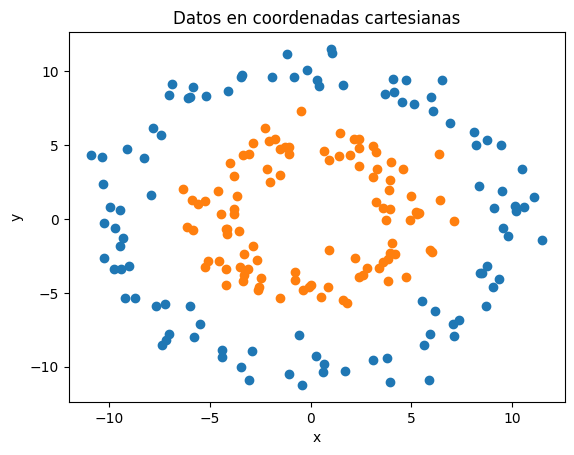

In [84]:
# Visualización
plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.title("Datos en coordenadas cartesianas")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [85]:
# Definimos una red que pueda aprender una representación de los datos
representation_layer = nn.Sequential(
    nn.Linear(2, 128), nn.Tanh(), nn.Linear(128, 2), nn.Tanh()
)
output_layer = nn.Sequential(nn.Linear(2, 2), nn.Softmax(1))

In [86]:
# Convertibos nuestros datos a tensores
X = torch.Tensor(list(zip(x1, y1)) + list(zip(x2, y2)))
Y = torch.tensor([0 for i in range(100)] + [1 for i in range(100)])

In [87]:
epochs = 1000
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    list(representation_layer.parameters()) + list(output_layer.parameters()), lr=0.1
)
for t in range(epochs):
    y_pred = output_layer(representation_layer(X))
    optimizer.zero_grad()
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

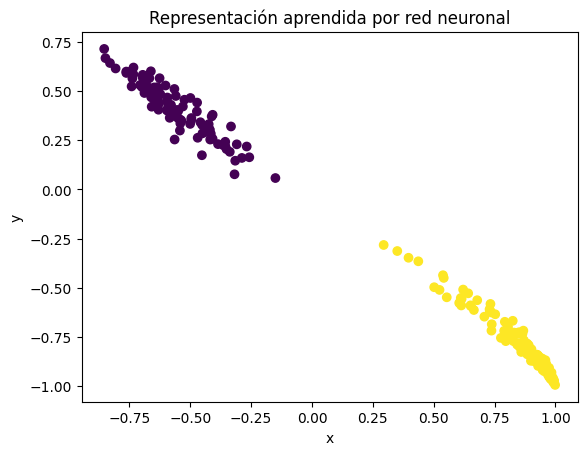

In [88]:
# Aplicamos la representación que aprendemos
representation = representation_layer(X).detach().numpy()

# Visualziación de representación aprendida
plt.scatter(representation[:, 0], representation[:, 1], c=Y)
plt.title("Representación aprendida por red neuronal")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

De esta forma, las redes neuronales profundas evitan la necesidad de definir de manera exhaustiva un conjunto de rasgos que represente a los datos. Sin embargo, también presenta una desventaja, pues las representaciones obtenidas no siempre son fáciles de interpretar.

### Codificación one-hot y embeddings

Cuando no conocemos los rasgos que pueden caracterizar a nuestros datos o en datos categóricos es común usar una representación one-hot, que es una representación indexal.

Por ejemplo, si tenemos 3 objetos que queremos clasificar, podemos asignarle a cada uno un índice de manera arbitraria, $\Omega = \{\omega_1, \omega_2, \omega_3\}$ donde el subíndice indica el índice que corresponde. 

Una representación one-hot crea un vector en base a este índice, de tal forma que los rasgos de cada objeto son:

$$x_i(j) = \begin{cases} 1 & \text{si } i = j \\ 0 & \text{en otro caso}\end{cases}$$

Por ejemplo, el objeto con el índice 2 $\omega_2$ tiene la representación:

$$x^T = \begin{pmatrix} 0 & 1 & 0 \end{pmatrix}$$

In [89]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import load_iris

In [90]:
iris_data = load_iris(as_frame=True)

In [91]:
iris_data.frame

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [96]:
ohe = OneHotEncoder()
iris_ohe_vectors = ohe.fit_transform(iris_data.frame[["target"]]).toarray()
rprint(iris_ohe_vectors[:10])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]

In [93]:
ohe.categories_

[array([0, 1, 2])]

#### ¿Qué problemas podemos tener con las one-hot?

## Word Embeddings

Por dentro de una red neuronal se puede aprender un encaje o **embedding** que consiste en multiplicar una matriz por el one-hot:

$$emb(x) = W \cdot x$$

Por ejemplo, si queremos una representación de dos dimensiones de objeto anterior, tenemos:

$$emb\big(x(2)\big) = \begin{pmatrix} 0.5 & 1 & 0.7 \\ 0.3 & 0.3 & 1 \end{pmatrix} \begin{pmatrix} 0 \\ 1 \\ 0\end{pmatrix} \begin{pmatrix} 1 \\ 0.3 \end{pmatrix} $$

Se puede notar que este producto equivale a tomar el segundo vector columna de la matriz como representación; es decir, tenemos que $emb(j) = W.T[j]$.

En paqueterías especialzadas en redes neuronales tenemos ya implementadas este tipo de funciones para crear representaciones. Por ejemplo, en pytorch, podemos usar el modulo de Embedding. de la forma:

```python
torch.nn.Embedding(num_índices, dimensión_de_representación)
```

In [94]:
# Definimos la función de representación
emb = nn.Embedding(
    100, 3
)  # Trabajará con 100 índices, y creará vectores 3-dimensionales

# Dado un índice regresa un vector de la dimensión definida
print(emb(torch.tensor([1])))

tensor([[0.4786, 1.1665, 0.2443]], grad_fn=<EmbeddingBackward0>)


In [102]:
# Podemos generar representaciones para varios índices
print(emb(torch.tensor([1, 2, 50, 99])))

tensor([[ 0.4786,  1.1665,  0.2443],
        [-0.4625,  0.2585, -0.3398],
        [ 1.0592,  0.2558, -0.9102],
        [ 1.0916,  1.1822,  0.9117]], grad_fn=<EmbeddingBackward0>)


In [109]:
target_indices = iris_data.frame["target"].astype("category").cat.codes.values

In [111]:
target_tensor = torch.tensor(target_indices, dtype=torch.long)
iris_embeddings = emb(target_tensor)

In [ ]:
rprint(iris_embeddings[:10])

tensor([[-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376],
        [-0.1987, -0.0790, -0.0376]], grad_fn=<SliceBackward0>)